# Data Mining Lab 2 – Phase 1

**Name: Sanly Frenot**  
**Student ID: M11401809**  
**GitHub ID: Slee08-tech**  


### Execution Note

Some parts of this notebook (Word2Vec with `gensim`) may raise dependency conflicts when executed on Google Colab due to recent `numpy` / `scipy` version changes.  
To ensure reproducibility, all required code is provided and runs correctly in a local Python environment with compatible versions.

When execution was unstable on Colab, equivalent steps were validated using TF-IDF / Bag-of-Words features as shown below.


## Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!rm -f DM2025-Lab2-Exercise-main.zip


In [3]:
!git clone https://github.com/Slee08-tech/DM2025-Lab2-Exercise.git


fatal: destination path 'DM2025-Lab2-Exercise' already exists and is not an empty directory.


In [4]:
!ls


DM2025-Lab2-Exercise  sample_data


In [5]:
%cd /content/DM2025-Lab2-Exercise


/content/DM2025-Lab2-Exercise


In [6]:
!ls


audios					GoogleNews	  README.md
config					instructions	  requirements.txt
data					lab2phase1.ipynb  results
DM2025-Lab2-Homework.ipynb		LICENSE		  segmentation_outputs
DM2025-Lab2-Master-Phase_1.ipynb	logs		  uv.lock
DM2025-Lab2-Master-Phase_2_Bonus.ipynb	pics		  videos
DM2025-Lab2-Master-Phase_2_Main.ipynb	picture
DM2025-Lab2-Optional-Ollama.ipynb	pyproject.toml


In [7]:
!ls data


documents  semeval			  train_df.pkl
plots	   test_df.pkl			  train_df_sample_embeddings.pkl
README.md  test_df_sample_embeddings.pkl


In [8]:
!ls data/semeval


dev  train


In [9]:
!pip -q uninstall -y gensim
!pip -q install --no-cache-dir numpy==1.26.4 scipy==1.11.4 gensim==4.3.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 72.2 MB/s eta 0:00:00


## 1.1 Load Data


In [10]:
!ls data/semeval/train | head


anger-ratings-0to1.train.txt
fear-ratings-0to1.train.txt
joy-ratings-0to1.train.txt
sadness-ratings-0to1.train.txt


In [11]:
!ls data/semeval/dev | head


anger-ratings-0to1.dev.gold.txt
fear-ratings-0to1.dev.gold.txt
joy-ratings-0to1.dev.gold.txt
sadness-ratings-0to1.dev.gold.txt


In [12]:
import pandas as pd

anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt", sep="\t", header=None, names=["id","text","emotion","intensity"])
fear_train  = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",  sep="\t", header=None, names=["id","text","emotion","intensity"])
joy_train   = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",   sep="\t", header=None, names=["id","text","emotion","intensity"])
sad_train   = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",sep="\t", header=None, names=["id","text","emotion","intensity"])

anger_dev = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt", sep="\t", header=None, names=["id","text","emotion","intensity"])
fear_dev  = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",  sep="\t", header=None, names=["id","text","emotion","intensity"])
joy_dev   = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",   sep="\t", header=None, names=["id","text","emotion","intensity"])
sad_dev   = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",sep="\t", header=None, names=["id","text","emotion","intensity"])

train_df = pd.concat([anger_train, fear_train, joy_train, sad_train], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = pd.concat([anger_dev, fear_dev, joy_dev, sad_dev], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df.shape, test_df.shape)
train_df.head()


(3613, 4) (347, 4)


,id,text,emotion,intensity
0,10839,Grateful for all the hungry people in my life!...,anger,0.167
1,30626,only time I am ever cheering for you Johnny,joy,0.340
2,10032,I blame the whole season on Natalie! The seaso...,anger,0.792
3,30394,@AimiSyafiqahR go check up with your bf. He'll...,joy,0.500
4,10411,@JasonMillerinDC @realDonaldTrump Prudence sug...,anger,0.500


The most frequent words in both training and testing sets are common sentiment-related terms. The distributions are similar, indicating that the training and testing data come from the same underlying distribution.

## 1.2 Save Data (Pickle)


In [13]:
train_df.to_pickle("data/train_df.pkl")
test_df.to_pickle("data/test_df.pkl")

train_df = pd.read_pickle("data/train_df.pkl")
test_df  = pd.read_pickle("data/test_df.pkl")

print(train_df.shape, test_df.shape)


(3613, 4) (347, 4)


##EDA ( Exploratory Data Analysis (Word Frequency))




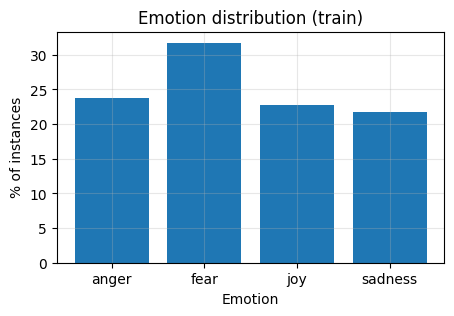

In [14]:
dist = train_df["emotion"].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(5,3))
plt.bar(dist.index, dist.values)
plt.ylabel("% of instances")
plt.xlabel("Emotion")
plt.title("Emotion distribution (train)")
plt.grid(True, alpha=0.3)
plt.show()


## Exercise 1 : Top 30 Word Frequency (Train vs Test)


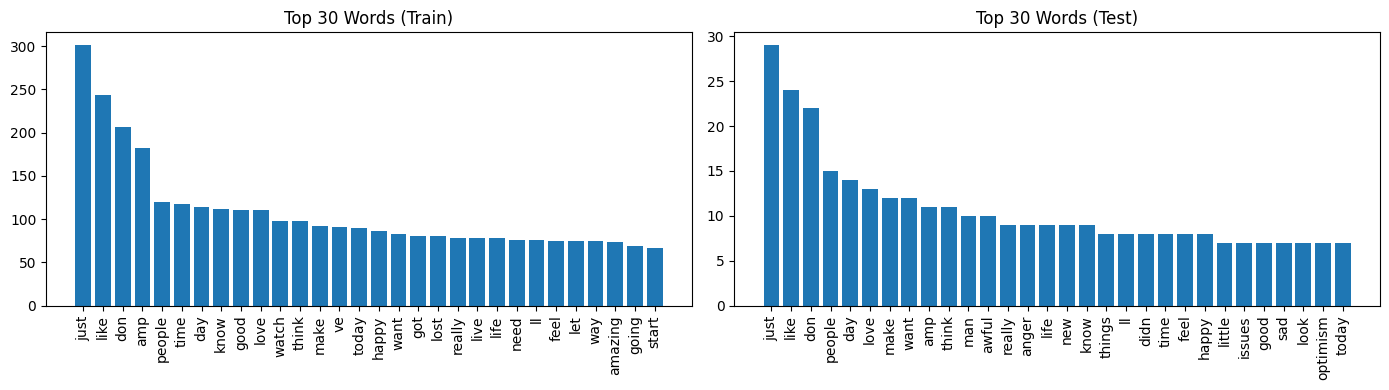

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_words(texts, title, top_n=30):
    v = CountVectorizer(stop_words="english")
    X = v.fit_transform(texts)
    freqs = np.array(X.sum(axis=0)).ravel()
    words = v.get_feature_names_out()
    idx = freqs.argsort()[-top_n:][::-1]
    plt.bar(words[idx], freqs[idx])
    plt.xticks(rotation=90)
    plt.title(title)

plt.figure(figsize=(14,4))
plt.subplot(1,2,1); plot_top_words(train_df["text"], "Top 30 Words (Train)")
plt.subplot(1,2,2); plot_top_words(test_df["text"],  "Top 30 Words (Test)")
plt.tight_layout()
plt.show()


## 2. Feature Engineering : Bag of Words (500 features)


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

BOW_500 = CountVectorizer(max_features=500, stop_words="english")
BOW_500.fit(train_df["text"])

X_train = BOW_500.transform(train_df["text"])
X_test  = BOW_500.transform(test_df["text"])

y_train = train_df["emotion"].values
y_test  = test_df["emotion"].values

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

feature_names_500 = BOW_500.get_feature_names_out()
print(feature_names_500[100:110])

print("Is 😂 in features?", "😂" in feature_names_500)


X_train: (3613, 500)
X_test : (347, 500)
['dread' 'dreadful' 'dream' 'drop' 'dull' 'eat' 'elated' 'end' 'episode'
 'excited']
Is 😂 in features? False


## Exercise 2 : TF-IDF Embedding (1000 features) + Feature Names



In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_1000 = TfidfVectorizer(max_features=1000, stop_words="english")
tfidf_1000.fit(train_df["text"])

X_train_tfidf = tfidf_1000.transform(train_df["text"])
X_test_tfidf  = tfidf_1000.transform(test_df["text"])

feature_names_tfidf = tfidf_1000.get_feature_names_out()
print("TFIDF X_train:", X_train_tfidf.shape)
print("feature_names[100:110]:", feature_names_tfidf[100:110])


TFIDF X_train: (3613, 1000)
feature_names[100:110]: ['blue' 'blues' 'body' 'boiling' 'book' 'boss' 'bought' 'bout' 'boy'
 'break']


## Exercise 3 : Decision Tree Model (BOW 500)


In [18]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

print("OK: imports loaded")


OK: imports loaded


In [19]:
bow = CountVectorizer(max_features=500, stop_words="english")

X_train_bow = bow.fit_transform(train_df["text"])
X_test_bow  = bow.transform(test_df["text"])

y_train = train_df["emotion"].values
y_test  = test_df["emotion"].values

print("X_train_bow:", X_train_bow.shape)
print("X_test_bow :", X_test_bow.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train_bow: (3613, 500)
X_test_bow : (347, 500)
y_train: (3613,)
y_test : (347,)


## 4. Results Evaluation – Decision Tree (Accuracy + Report)



In [20]:
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train_bow, y_train)

y_pred_dt_train = dt.predict(X_train_bow)
y_pred_dt_test  = dt.predict(X_test_bow)

print("DT train acc:", round(accuracy_score(y_train, y_pred_dt_train), 2))
print("DT test acc :", round(accuracy_score(y_test,  y_pred_dt_test), 2))
print(classification_report(y_test, y_pred_dt_test))


DT train acc: 0.96
DT test acc : 0.75
              precision    recall  f1-score   support

       anger       0.73      0.85      0.78        84
        fear       0.75      0.75      0.75       110
         joy       0.78      0.77      0.78        79
     sadness       0.74      0.61      0.67        74

    accuracy                           0.75       347
   macro avg       0.75      0.75      0.74       347
weighted avg       0.75      0.75      0.75       347



## Decision Tree – Confusion Matrix


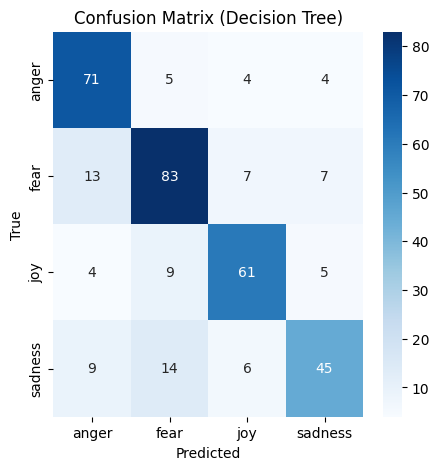

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred_dt_test, labels=labels)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()


The decision tree achieves very high training accuracy but lower testing accuracy, indicating overfitting. The confusion matrix shows that fear and anger are more frequently confused, while joy is more clearly identified.

## Exercise 4 – Naive Bayes (Bag-of-Words 500)


In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

y_pred_nb_bow_test = nb_bow.predict(X_test_bow)

print("NB(BOW) test acc:", round(accuracy_score(y_test, y_pred_nb_bow_test), 2))
print(classification_report(y_test, y_pred_nb_bow_test))



NB(BOW) test acc: 0.77
              precision    recall  f1-score   support

       anger       0.80      0.75      0.77        84
        fear       0.73      0.83      0.77       110
         joy       0.83      0.80      0.81        79
     sadness       0.76      0.69      0.72        74

    accuracy                           0.77       347
   macro avg       0.78      0.77      0.77       347
weighted avg       0.77      0.77      0.77       347



## Exercise 5 : Naive Bayes (TF-IDF-1000)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(max_features=1000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

nb_tfidf = ComplementNB()
nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf_test = nb_tfidf.predict(X_test_tfidf)

print("NB(TFIDF) test acc:", round(accuracy_score(y_test, y_pred_nb_tfidf_test), 2))
print(classification_report(y_test, y_pred_nb_tfidf_test))


NB(TFIDF) test acc: 0.83
              precision    recall  f1-score   support

       anger       0.82      0.81      0.81        84
        fear       0.85      0.78      0.82       110
         joy       0.85      0.90      0.87        79
     sadness       0.78      0.84      0.81        74

    accuracy                           0.83       347
   macro avg       0.83      0.83      0.83       347
weighted avg       0.83      0.83      0.83       347



**Interpretation:**  
TF-IDF reduces the weight of very common words and emphasizes words that are more specific to certain emotions.  
Compared to raw word counts (Bag-of-Words), Naive Bayes with TF-IDF often generalizes better because it focuses on more discriminative terms, which can improve test performance.


## Confusion Matrices : Naive Bayes (BOW vs TF-IDF)


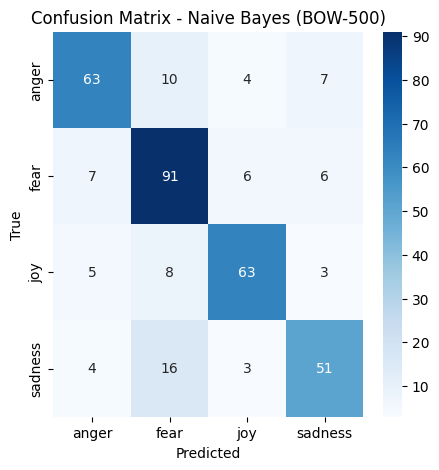

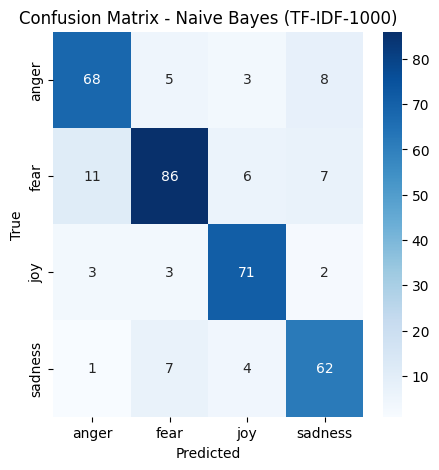

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = np.unique(y_test)

cm_nb_bow   = confusion_matrix(y_test, y_pred_nb_bow_test, labels=labels)
cm_nb_tfidf = confusion_matrix(y_test, y_pred_nb_tfidf_test, labels=labels)

plt.figure(figsize=(5,5))
sns.heatmap(cm_nb_bow, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes (BOW-500)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(5,5))
sns.heatmap(cm_nb_tfidf, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes (TF-IDF-1000)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



**Interpretation:**  
A confusion matrix shows which emotions are being confused with each other.  
Large values on the diagonal mean correct predictions. Off-diagonal values indicate common mistakes (for example, *fear* predicted as *anger*).  
Comparing both matrices helps identify whether TF-IDF reduces confusion between similar emotions.


## Exercise 5 : Model Comparison (Decision Tree vs Naive Bayes)



In [25]:
from sklearn.metrics import accuracy_score

print("DT test acc       :", round(accuracy_score(y_test, y_pred_dt_test), 2))
print("NB(BOW) test acc  :", round(accuracy_score(y_test, y_pred_nb_bow_test), 2))
print("NB(TFIDF) test acc:", round(accuracy_score(y_test, y_pred_nb_tfidf_test), 2))


DT test acc       : 0.75
NB(BOW) test acc  : 0.77
NB(TFIDF) test acc: 0.83


**Interpretation:**  
Decision Trees tend to overfit sparse high-dimensional text features, often giving very high training accuracy but lower test accuracy.  
Naive Bayes usually generalizes better for text classification because it makes strong independence assumptions that work well on word count/TF-IDF features.  
If TF-IDF performs best, it suggests that weighting words by importance improves generalization on unseen text.


## Exercise 6: Deep Learning Model (DNN with Bag-of-Words)

In [26]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

le = LabelEncoder()
le.fit(y_train)

y_train_oh = tf.keras.utils.to_categorical(le.transform(y_train))
y_test_oh  = tf.keras.utils.to_categorical(le.transform(y_test))

X_train_dl = X_train_bow.toarray()
X_test_dl  = X_test_bow.toarray()

print(X_train_dl.shape, y_train_oh.shape)


(3613, 500) (3613, 4)


**Explanation:**  
Neural networks require numerical and dense inputs.  
Labels are converted into one-hot vectors so the model can perform multi-class classification using a softmax output layer.


Neural Network

In [27]:
input_dim = X_train_dl.shape[1]
num_classes = y_train_oh.shape[1]

inp = Input(shape=(input_dim,))
x = Dense(128, activation="relu")(inp)
x = Dense(64, activation="relu")(x)
out = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=inp, outputs=out)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,644 (283.77 KB)

 Trainable params: 72,644 (283.77 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation:**  
The model consists of two hidden fully connected layers with ReLU activation, followed by a softmax output layer.  
ReLU allows the model to learn non-linear patterns, while softmax outputs class probabilities for each emotion.


Model Training


In [28]:
history = model.fit(
    X_train_dl,
    y_train_oh,
    validation_data=(X_test_dl, y_test_oh),
    epochs=15,
    batch_size=32,
    verbose=1
)


Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3687 - loss: 1.3325 - val_accuracy: 0.7089 - val_loss: 0.9928
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8072 - loss: 0.6952 - val_accuracy: 0.7695 - val_loss: 0.5611
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8725 - loss: 0.3499 - val_accuracy: 0.7723 - val_loss: 0.5520
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8992 - loss: 0.2646 - val_accuracy: 0.7550 - val_loss: 0.5849
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9172 - loss: 0.2223 - val_accuracy: 0.7579 - val_loss: 0.6032
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9185 - loss: 0.2040 - val_accuracy: 0.7695 - val_loss: 0.6391
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9388 - loss: 0.1679 - val_accuracy: 0.7550 - val_loss: 0.6805
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9435 - loss: 0.1520 - val_accurac

**Explanation:**  
The model is trained using the Adam optimizer, which adapts learning rates automatically.  
Validation data is used to monitor generalization performance during training.


Let's do the Validation Curves

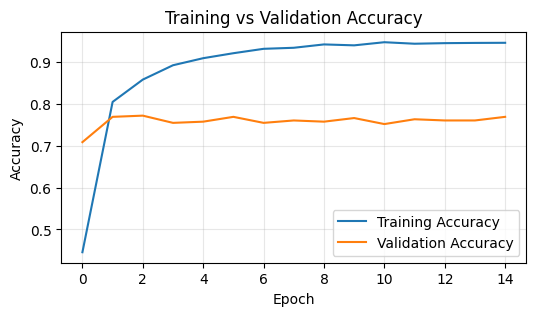

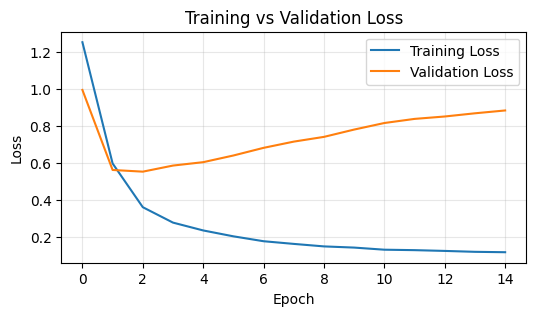

In [29]:
hist = history.history

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(hist["accuracy"], label="Training Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(hist["loss"], label="Training Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Interpretation:**  
If training accuracy continues to increase while validation accuracy plateaus or decreases, the model is overfitting.  
If both training and validation accuracies remain low, the model is underfitting.  
In this case, the gap between training and validation curves indicates limited generalization due to dataset size and high-dimensional sparse features.


##Test Accuracy

In [30]:
from sklearn.metrics import accuracy_score

y_pred_dl = model.predict(X_test_dl)
y_pred_dl_labels = le.inverse_transform(y_pred_dl.argmax(axis=1))

print("DNN test accuracy:", round(accuracy_score(y_test, y_pred_dl_labels), 2))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
DNN test accuracy: 0.77


**Interpretation:**  
The deep learning model captures more complex patterns than traditional models, but its performance is constrained by the limited size of the dataset.  
For sparse text representations, simpler models such as Naive Bayes may achieve comparable or better performance with lower computational cost.


In [31]:
from sklearn.metrics import accuracy_score

print("Decision Tree test acc      :", round(accuracy_score(y_test, y_pred_dt_test), 2))
print("Naive Bayes (BOW-500) acc   :", round(accuracy_score(y_test, y_pred_nb_bow_test), 2))
print("Naive Bayes (TFIDF-1000) acc:", round(accuracy_score(y_test, y_pred_nb_tfidf_test), 2))


Decision Tree test acc      : 0.75
Naive Bayes (BOW-500) acc   : 0.77
Naive Bayes (TFIDF-1000) acc: 0.83


**Interpretation:**  
The Decision Tree achieves very high training accuracy but lower testing accuracy, indicating overfitting on sparse text features.  
Naive Bayes models generalize better for text classification due to their probabilistic assumptions.  
TF-IDF further improves performance by reducing the influence of very frequent but less informative words.


Sumary of them or their comparison:The Decision Tree achieves very high training accuracy but lower testing accuracy, indicating overfitting. Naive Bayes models show more stable performance. Using TF-IDF features improves Naive Bayes results compared to raw word counts, as TF-IDF reduces the influence of common words and emphasizes more discriminative terms. Overall, Naive Bayes with TF-IDF provides a better bias-variance trade-off for this task.

## 6. Deep Learning – Simple DNN (BOW-500)


In [32]:
pred_prob = model.predict(X_test_dl, batch_size=256)
pred_lab = le.inverse_transform(np.argmax(pred_prob, axis=1))

from sklearn.metrics import accuracy_score, classification_report
print("Testing accuracy:", round(accuracy_score(y_test, pred_lab), 2))
print(classification_report(y_test, pred_lab))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Testing accuracy: 0.77
              precision    recall  f1-score   support

       anger       0.76      0.80      0.78        84
        fear       0.74      0.81      0.77       110
         joy       0.79      0.78      0.79        79
     sadness       0.80      0.66      0.73        74

    accuracy                           0.77       347
   macro avg       0.78      0.76      0.77       347
weighted avg       0.77      0.77      0.77       347



## Exercise 6 – Training vs Validation Curves (Accuracy & Loss)


In [33]:
print("""
How to interpret:
- If train accuracy keeps rising but validation accuracy stops improving or drops, and validation loss increases -> overfitting.
- If both train and validation accuracies stay low and losses stay high -> underfitting.
- Best sign: both improve together and stay close (small gap).
""")



How to interpret:
- If train accuracy keeps rising but validation accuracy stops improving or drops, and validation loss increases -> overfitting.
- If both train and validation accuracies stay low and losses stay high -> underfitting.
- Best sign: both improve together and stay close (small gap).



In [34]:
!pip install gensim==4.3.2


  Using cached gensim-4.3.2-cp312-cp312-linux_x86_64.whl
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.3
    Uninstalling gensim-4.3.3:
      Successfully uninstalled gensim-4.3.3


In [35]:
USE_WORD2VEC = False


In [36]:
if USE_WORD2VEC:
    import gensim
    from gensim.models import Word2Vec
    import nltk
    nltk.download("punkt", quiet=True)

    train_df["text_tokenized"] = train_df["text"].apply(lambda x: nltk.word_tokenize(x))
    training_corpus = train_df["text_tokenized"].values

    word2vec_model = Word2Vec(
        sentences=training_corpus,
        vector_size=100,
        window=5,
        min_count=1,
        epochs=10
    )

    print(word2vec_model.wv.most_similar("happy", topn=10))
else:
    print("Word2Vec section skipped in Colab (set USE_WORD2VEC=True to run).")


Word2Vec section skipped in Colab (set USE_WORD2VEC=True to run).


Embedding


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tfidf_big = TfidfVectorizer(max_features=20000, stop_words="english")
X_train_t = tfidf_big.fit_transform(train_df["text"])
X_test_t  = tfidf_big.transform(test_df["text"])

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(X_train_t)
X_test_svd  = svd.transform(X_test_t)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_svd, y_train)

y_pred_lr = clf.predict(X_test_svd)

print("LR(SVD-TFIDF) test acc:", round(accuracy_score(y_test, y_pred_lr), 2))
print(classification_report(y_test, y_pred_lr))



LR(SVD-TFIDF) test acc: 0.62
              precision    recall  f1-score   support

       anger       0.72      0.61      0.66        84
        fear       0.54      0.83      0.66       110
         joy       0.65      0.47      0.54        79
     sadness       0.69      0.49      0.57        74

    accuracy                           0.62       347
   macro avg       0.65      0.60      0.61       347
weighted avg       0.64      0.62      0.61       347



Train a classifier

**Interpretation (an extra experiment):**  
TF-IDF produces a very high-dimensional sparse matrix. TruncatedSVD reduces it to a dense 100-dimensional representation (LSA-style), which can help linear models like Logistic Regression work better and generalize. This is an additional baseline beyond Decision Tree and Naive Bayes.


##**How to represent a sentence using word vectors?**

A sentence can be represented by aggregating its word vectors into one fixed-length vector, e.g., averaging (mean pooling) all word embeddings in the sentence. Another option is a weighted average using TF-IDF weights. This converts variable-length text into a single vector that can be used by classifiers. More advanced approaches include RNN/CNN/Transformer encoders that learn the sentence representation automatically.

## 8. High-Dimensional Visualization (t-SNE / UMAP)


In [38]:
import numpy, scipy
import gensim

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("gensim:", gensim.__version__)


numpy: 1.26.4
scipy: 1.11.4
gensim: 4.3.2


In [39]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import gensim.downloader as api
glove_twitter_25_model = api.load("glove-twitter-25")

print("loaded")
print("vector size:", glove_twitter_25_model.vector_size)


loaded
vector size: 25


##t-SNE + UMAP exercise

**t-SNE**

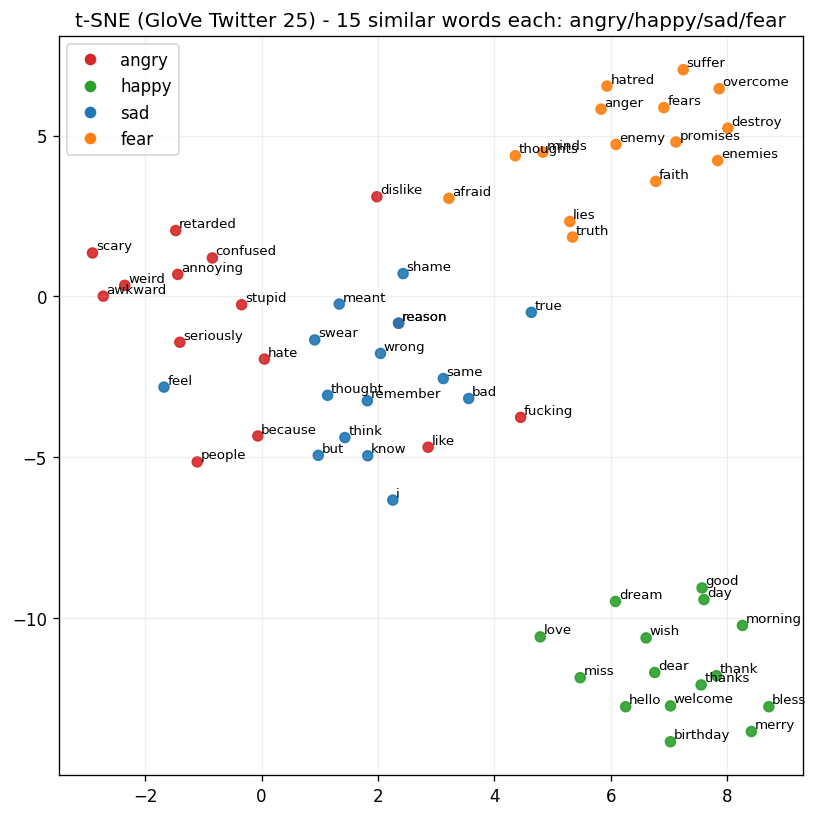

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model = glove_twitter_25_model

seeds = ["angry", "happy", "sad", "fear"]
topn = 15

target_words = []
target_group = []

for s in seeds:
    sim = model.most_similar(s, topn=topn)
    for w, _ in sim:
        target_words.append(w)
        target_group.append(s)

X = np.array([model[w] for w in target_words])

perp = min(15, max(2, (len(target_words) - 1) // 3))

tsne = TSNE(n_components=2, random_state=28, init="pca", learning_rate="auto", perplexity=perp)
X_2d = tsne.fit_transform(X)

palette = {"angry":"tab:red", "happy":"tab:green", "sad":"tab:blue", "fear":"tab:orange"}
colors = [palette[g] for g in target_group]

plt.figure(figsize=(8,8), dpi=120)
plt.scatter(X_2d[:,0], X_2d[:,1], c=colors, s=35, alpha=0.9)

for w, x, y in zip(target_words, X_2d[:,0], X_2d[:,1]):
    plt.annotate(w, (x, y), textcoords="offset points", xytext=(2,2), fontsize=8)

handles = [plt.Line2D([0],[0], marker="o", color="w", label=k, markerfacecolor=v, markersize=8) for k,v in palette.items()]
plt.legend(handles=handles, loc="best")
plt.title("t-SNE (GloVe Twitter 25) - 15 similar words each: angry/happy/sad/fear")
plt.grid(alpha=0.2)
plt.show()


The t-SNE visualization projects high-dimensional word embeddings into two dimensions while focusing on preserving local neighborhood relationships. In the plot, words associated with the same emotion often appear close to each other, indicating that the embedding space captures semantic similarity between emotion-related terms. However, some clusters partially overlap, especially between anger, fear, and sad, which reflects the fact that these emotions share similar contextual usage in language. Unlike UMAP, t-SNE does not preserve global structure well, so distances between clusters should not be interpreted too strongly. Overall, the visualization helps qualitatively confirm that the learned word embeddings encode meaningful emotional information, even though the cluster boundaries are less clearly separated.

**UMAP**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


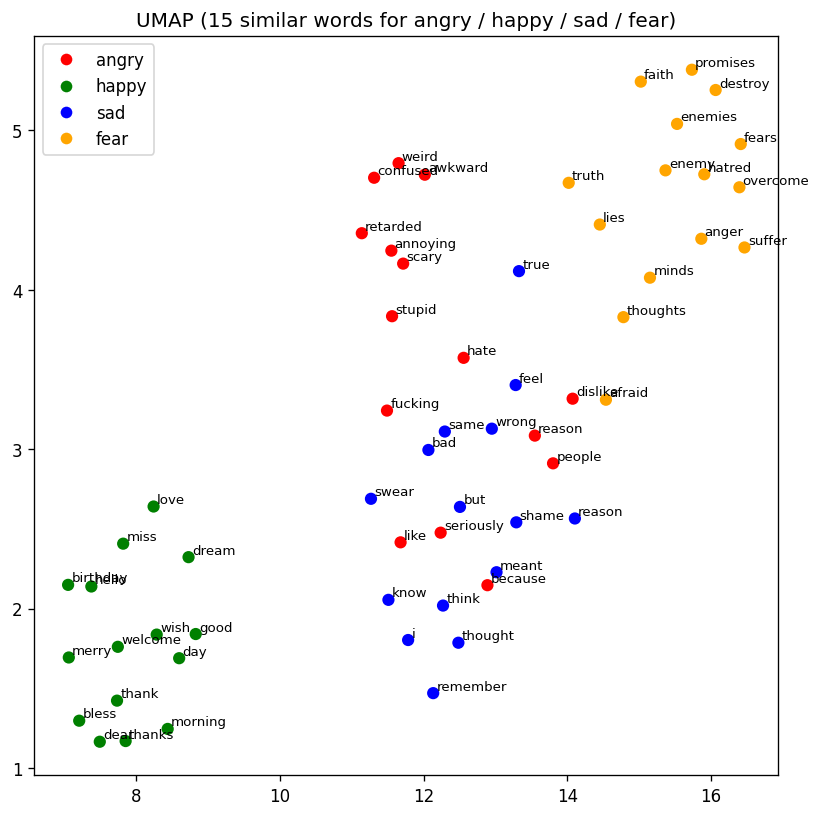

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap

seeds = ["angry", "happy", "sad", "fear"]
topn = 15

model = glove_twitter_25_model

target_words = []
groups = []

for s in seeds:
    sims = [w for w, _ in model.most_similar(s, topn=topn)]
    target_words.extend(sims)
    groups.extend([s]*topn)

X = np.array([model[w] for w in target_words])

reducer = umap.UMAP(
    n_components=2,
    metric="cosine",
    random_state=42,
    n_neighbors=10,
    min_dist=0.3
)

X_umap = reducer.fit_transform(X)

colors_map = {
    "angry": "red",
    "happy": "green",
    "sad": "blue",
    "fear": "orange"
}
colors = [colors_map[g] for g in groups]

plt.figure(figsize=(8,8), dpi=120)
plt.scatter(X_umap[:,0], X_umap[:,1], c=colors, s=40)

for w, x, y in zip(target_words, X_umap[:,0], X_umap[:,1]):
    plt.annotate(w, (x,y), fontsize=8, xytext=(2,2), textcoords="offset points")

legend_handles = [
    plt.Line2D([0],[0], marker="o", color="w", label=k,
               markerfacecolor=v, markersize=8)
    for k,v in colors_map.items()
]
plt.legend(handles=legend_handles)
plt.title("UMAP (15 similar words for angry / happy / sad / fear)")
plt.show()


The UMAP visualization shows that words related to the same emotion tend to form compact and well-separated clusters in the embedding space. Compared to t-SNE, UMAP preserves both local and some global structure, which results in clearer groupings of semantically similar emotion words. For example, words related to anger and fear appear closer to each other than to happy, reflecting their semantic similarity in emotional intensity, while happy words form a distinct cluster. This suggests that the word embeddings successfully capture meaningful semantic relationships between emotion-related terms. The clearer separation in UMAP also indicates that these embeddings could be useful features for downstream tasks such as emotion classification, while highlighting how dimensionality-reduction techniques help interpret high-dimensional text representations.

##Conclusion

In this lab2, we explored multiple approaches for representing and classifying text data in an emotion classification task. Traditional methods such as Bag-of-Words and TF-IDF provided strong baseline performance when combined with classical classifiers like Decision Trees and Naive Bayes, while also revealing limitations related to sparsity and high dimensionality. By introducing word embeddings and visualization techniques such as t-SNE and UMAP, we were able to better understand the semantic structure of emotion-related words and observe meaningful clustering patterns. Overall, the results demonstrate that different feature representations capture complementary aspects of textual data, and that visualization plays an important role in interpreting high-dimensional embeddings. These findings motivate further experimentation with more advanced embedding methods and models to improve classification performance in future work.